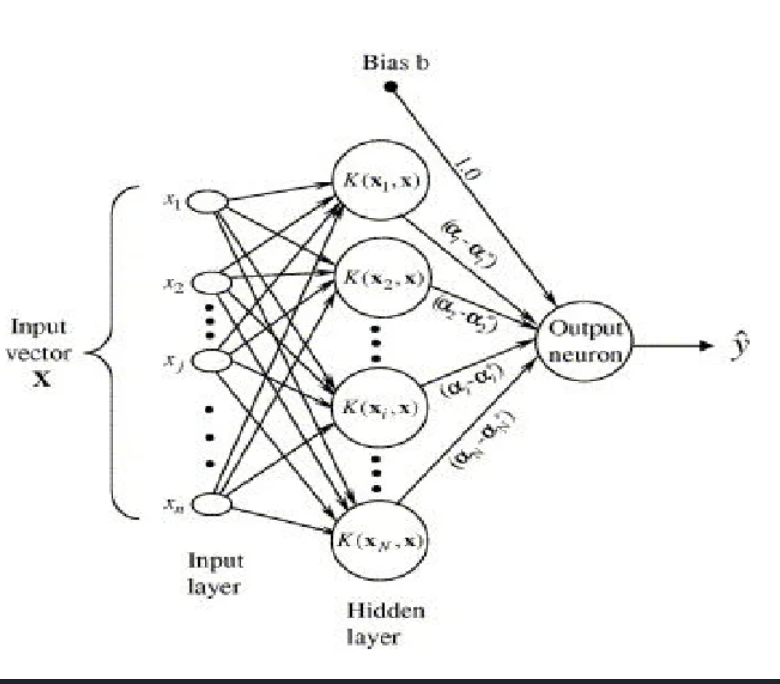

## IMPORTS

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.optim import AdamW
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import  ToTensor, Compose
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from ptflops import get_model_complexity_info

## Data Transformation and dataset split and Loading

In [2]:
mean=[0.4886, 0.4553, 0.4171]
std_dev=[0.2528, 0.2459, 0.2488]

In [3]:
custom_transform= transforms.Compose([
    transforms.Resize((64,64)),# resizes the image to 224 px x 224 px
    transforms.ToTensor(),   # converts the PIL image to Tensor
    transforms.Normalize(mean,std_dev)
])

In [4]:
dataset= ImageFolder(root="data", transform=custom_transform)

In [5]:
gen = torch.Generator().manual_seed(42)

In [6]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size

train_dataset, test_dataset= random_split(dataset, [train_size, test_size], generator=gen)

In [7]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False ,num_workers=2, pin_memory=True)

In [8]:
device = torch.device('mps')

## Class

In [9]:
class LinearSVM(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*3, 1)
        )

    def forward(self, x):
        return self.model(x)

## Model Object, loss, optim, schedular

In [10]:
model= LinearSVM().to(device)

In [11]:
def svm_loss(outputs, labels):

    hinge = torch.mean(

            torch.clamp(

                1-labels*outputs,

                min=0

            )

        )

    l2 = 0

    for p in model.parameters():
        l2 += torch.sum(p**2)

    return hinge + 1e-4*l2

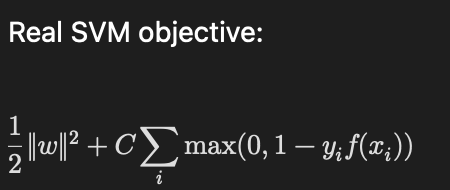

In [12]:
epochs=20

In [13]:
optim= AdamW(model.parameters(),lr=3e-4,weight_decay=1e-4)
schedular=CosineAnnealingLR(optim,T_max=epochs)

# TRAINING LOOP

In [14]:
start = time()

for epoch in tqdm(range(epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:
        labels = labels.float()
        labels = labels * 2 - 1
        labels = labels.unsqueeze(1).to(device)
        imgs = imgs.to(device)


        logits = model(imgs)

        l = svm_loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        # torch.where(condition, input, other)
        preds = torch.where(
            logits > 0,
            1,
            -1
        )# if logit >0 then mark it 1 or 0

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()
    schedular.step()
    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

  0%|          | 0/20 [00:00<?, ?it/s]/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  5%|▌         | 1/20 [00:34<10:50, 34.23s/it]

Loss Epoch 1: 0.9551
Accuracy Epoch 1: 57.17%


/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 10%|█         | 2/20 [01:06<09:52, 32.94s/it]

Loss Epoch 2: 0.9007
Accuracy Epoch 2: 59.65%


/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 15%|█▌        | 3/20 [01:34<08:43, 30.81s/it]

...

Loss Epoch 18: 0.7179
Accuracy Epoch 18: 69.28%


/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 95%|█████████▌| 19/20 [09:15<00:28, 28.27s/it]

Loss Epoch 19: 0.7132
Accuracy Epoch 19: 69.65%


/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 20/20 [09:44<00:00, 29.24s/it]

Loss Epoch 20: 0.7108
Accuracy Epoch 20: 69.68%


# TESTING LOOP

In [15]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = labels.float()
        labels = labels * 2 - 1
        labels = labels.unsqueeze(1).to(device)

        logits = model(imgs)

        l = svm_loss(
            logits,
            labels
        )



        preds = torch.where(
            logits > 0,
            1,
            -1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

Test Loss : 0.8491
Test Accuracy : 61.84%
Test Time : 17.94s


## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [24]:
from PIL import Image
model.eval()
dog = Image.open("/Users/par_04/code_playground/ml/Animal_classsfier/dog.jpeg").convert("RGB")
cat=Image.open("/Users/par_04/code_playground/ml/Animal_classsfier/cat.png").convert("RGB")
dog_tensor=custom_transform(dog)
cat_tensor=custom_transform(cat)

In [25]:
start= time()
infer_out1 = model(dog_tensor.unsqueeze(0).to(device))
infer_time1 = time()- start

In [26]:
predicton1= int(infer_out1 > 0.5)
predicton1=(predicton1+1)/2
decision_score1 = infer_out1.cpu().detach().float().item()

In [27]:
cls=["cat", "dog"]

In [28]:
predicton1

1.0

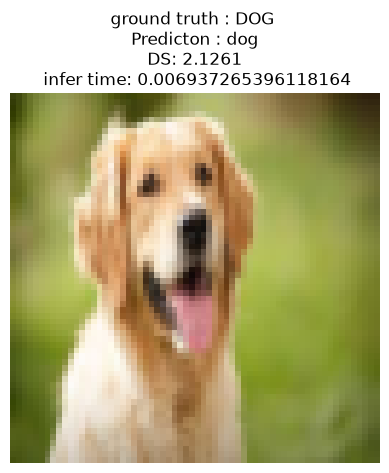

In [29]:
plt.title(f"ground truth : DOG \n Predicton : {cls[int(predicton1)]} \n DS: {decision_score1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
mean=torch.tensor(mean)
std_dev=torch.tensor(std_dev)
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [30]:
start= time()
infer_out2 = model(cat_tensor.unsqueeze(0).to(device))
infer_time2 = time()- start

In [31]:
predicton2= int(infer_out2 > 0.5)
predicton2=(predicton2+1)/2
decision_score2  = infer_out2.cpu().detach().float().item()

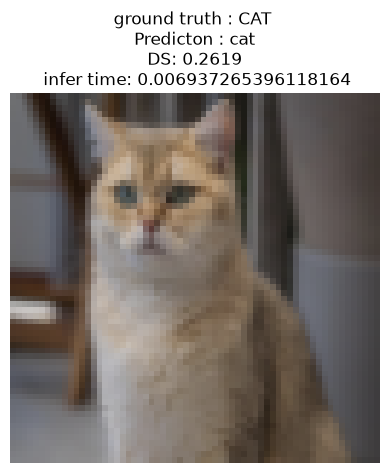

In [33]:
plt.title(f"ground truth : CAT \n Predicton : {cls[int(predicton2)]} \n DS: {decision_score2:.4f} \n infer time: {infer_time1}")
img= cat_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [35]:
num_paramerters=0
for p in model.parameters():
    num_paramerters+=p.numel()
    #weights
    #bias

In [36]:
memory_usage= torch.mps.current_allocated_memory()/1024**2

In [37]:
macs, params = get_model_complexity_info(model,(3,64,64),as_strings=False,print_per_layer_stat=False)

In [38]:
flops= macs*2

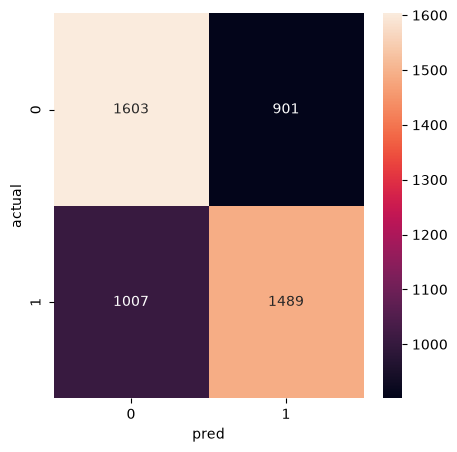

In [39]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [41]:
print("="*60)
print("LINEAR SVM EVALUATION RESULTS")
print("="*60)

print(f"Model         : Linear SVM")
print(f"Epochs        : {epochs}")

print()

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {pre[0]:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")

print()

print(f"Training Time : {train_time:.2f}s")
print(f"Testing Time  : {test_time:.2f}s")

print()

print(f"Parameters    : {num_paramerters:,}")
print(f"Memory Usage  : {memory_usage:.2f} MB")

print()

print("Classes       :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

LINEAR SVM EVALUATION RESULTS
Model         : Linear SVM
Epochs        : 20

Accuracy      : 0.6184
Precision     : 0.6230
Recall        : 0.5966
F1 Score      : 0.6095

Training Time : 584.75s
Testing Time  : 17.94s

Parameters    : 12,289
Memory Usage  : 0.71 MB

Classes       : ['cat', 'dog']

Confusion Matrix
[[1603  901]
 [1007 1489]]


In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       0.61      0.64      0.63      2504
         dog       0.62      0.60      0.61      2496

    accuracy                           0.62      5000
   macro avg       0.62      0.62      0.62      5000
weighted avg       0.62      0.62      0.62      5000

